# Import Required Libraries

Import the necessary Python libraries, such as yfinance for financial data, pandas for data manipulation, numpy for calculations, and matplotlib or seaborn for visualizations.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/Users/grtk/opt/anaconda3/envs/py313/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# Fetch Historical Data for USO ETF

Use yfinance to download historical price data for the USO ETF over a given period, including open, close prices, volumes, etc.

In [8]:
uso = yf.Ticker("USO")
data = uso.history(period="5y")
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2021-03-15 00:00:00-04:00,43.900002,44.340000,43.459999,44.259998,5710000,0.0,0.0,0.0
2021-03-16 00:00:00-04:00,43.570000,44.099998,43.320000,43.830002,4932400,0.0,0.0,0.0
2021-03-17 00:00:00-04:00,43.689999,43.930000,43.240002,43.820000,5837900,0.0,0.0,0.0
2021-03-18 00:00:00-04:00,42.990002,43.060001,39.709999,40.470001,18801800,0.0,0.0,0.0
2021-03-19 00:00:00-04:00,40.830002,41.990002,40.259998,41.770000,6430000,0.0,0.0,0.0


# Analyze Price Trends and Technical Indicators

Calculate and analyze technical indicators like moving averages, RSI, or Bollinger Bands to identify potential bearish trends on USO.

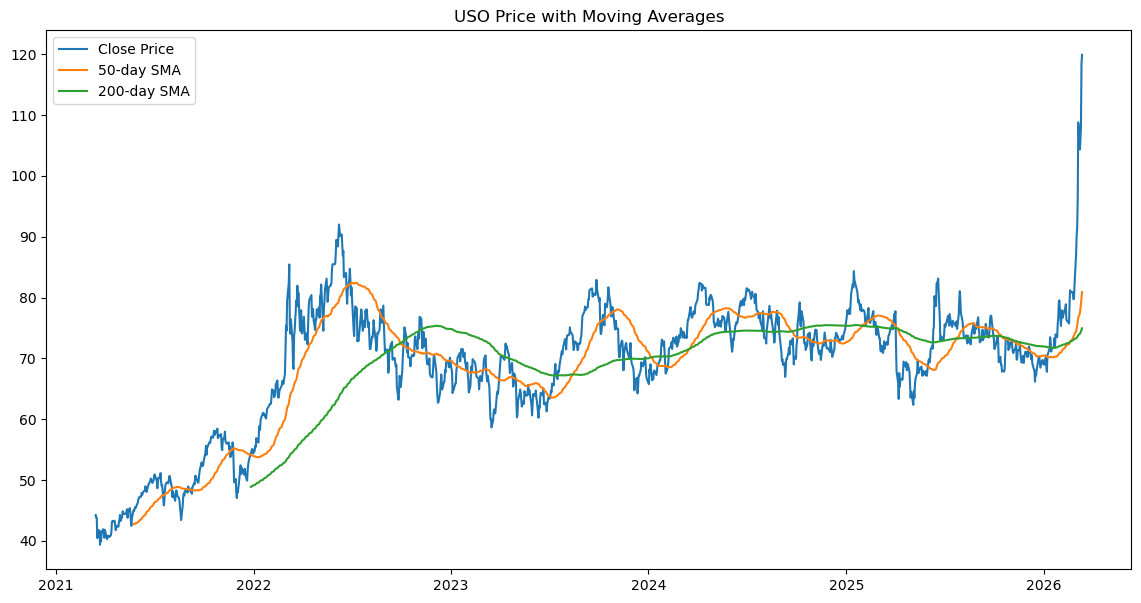

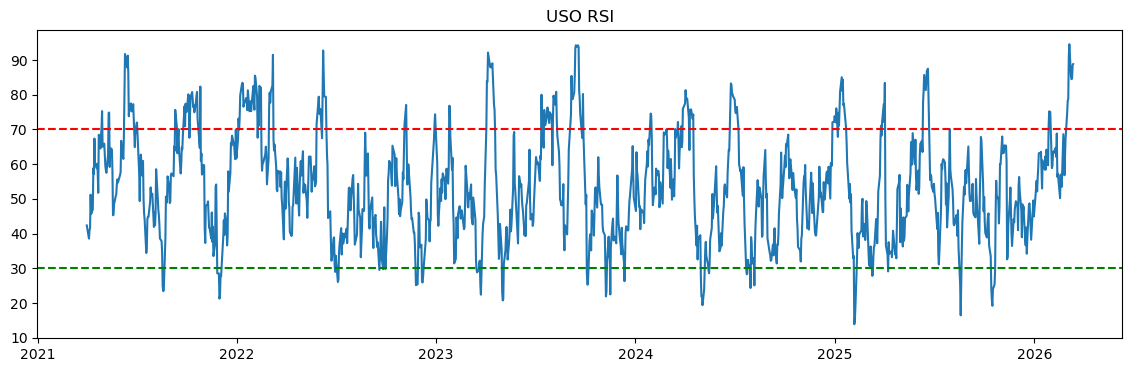

In [12]:
def calculate_rsi(data, window=14):
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

data['SMA_50'] = data['Close'].rolling(window=50).mean()
data['SMA_200'] = data['Close'].rolling(window=200).mean()
data['RSI'] = calculate_rsi(data)

plt.figure(figsize=(14,7))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['SMA_50'], label='50-day SMA')
plt.plot(data['SMA_200'], label='200-day SMA')
plt.title('USO Price with Moving Averages')
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.plot(data['RSI'], label='RSI')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title('USO RSI')
plt.show()

# Calculate Short Selling Metrics

Calculate key metrics for short selling, such as potential return, stock borrowing fees, and associated costs.

In [13]:
data['Returns'] = data['Close'].pct_change()
short_returns = -data['Returns']
mean_short_return = short_returns.mean()
std_short_return = short_returns.std()
sharpe = mean_short_return / std_short_return * np.sqrt(252)  # annualized Sharpe
print(f"Mean Daily Short Return: {mean_short_return:.6f}")
print(f"Std Dev Daily Short Return: {std_short_return:.6f}")
print(f"Annualized Sharpe Ratio: {sharpe:.4f}")
# Note: Borrowing fees for USO are typically low but variable; check current rates.

Mean Daily Short Return: -0.001028
Std Dev Daily Short Return: 0.021576
Annualized Sharpe Ratio: -0.7561


# Evaluate Risks Associated with Short Selling

Evaluate risks, including unlimited loss potential, margin calls, and the impact of dividends or unexpected events on USO.

In [14]:
VaR_95 = -np.percentile(short_returns.dropna(), 5)
print(f"95% Daily VaR for Short Position: {VaR_95:.6f}")

cum_returns = (1 + short_returns).cumprod()
peak = cum_returns.expanding().max()
drawdown = (cum_returns - peak) / peak
max_drawdown = drawdown.min()
print(f"Max Drawdown: {max_drawdown:.4f}")

dividends = uso.dividends
total_dividends = dividends.sum()
print(f"Total Dividends Paid over period: {total_dividends:.2f}")
# Note: Dividends are costs to short sellers. Unlimited loss if price rises indefinitely. Margin calls possible.

95% Daily VaR for Short Position: 0.033003
Max Drawdown: -0.8154
Total Dividends Paid over period: 0.00


# Simulate a Short Selling Strategy

Implement a backtest simulation of a short selling strategy on USO, using entry and exit conditions based on technical thresholds.

Strategy Total Return: -0.3423


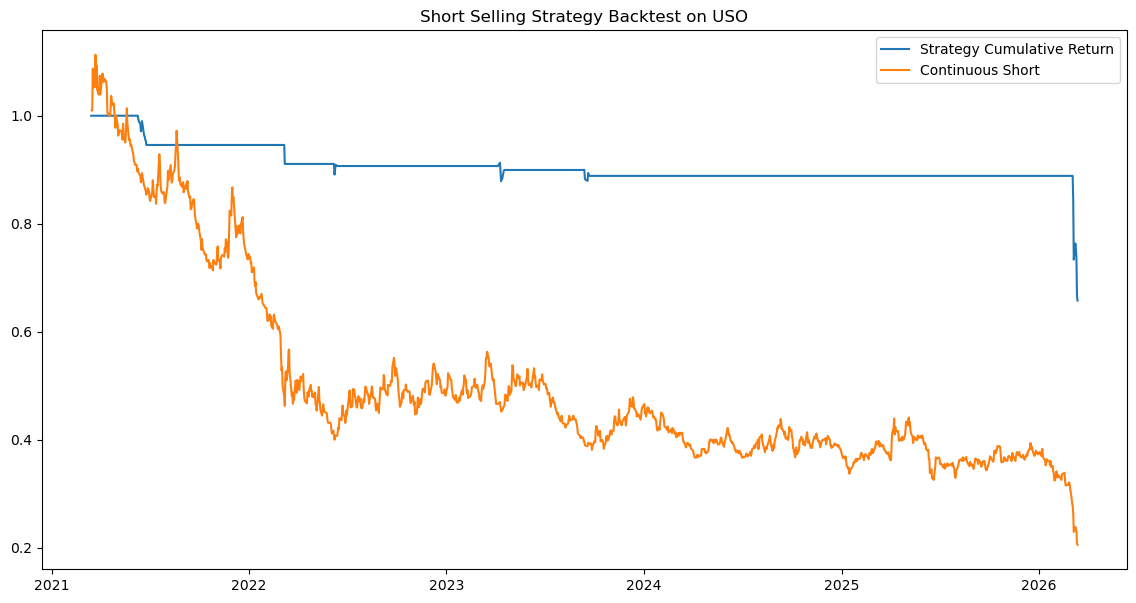

In [20]:
# Simple strategy: Enter short when RSI > 70, exit when RSI < 30
position = 0
strategy_returns = []
for i in range(len(data)):
    if data['RSI'].iloc[i] > 90 and position == 0:
        position = 1
    elif data['RSI'].iloc[i] < 70 and position == 1:
        position = 0
    if position == 1:
        strategy_returns.append(-data['Returns'].iloc[i])
    else:
        strategy_returns.append(0)
strategy_returns = pd.Series(strategy_returns, index=data.index)
cum_strategy = (1 + strategy_returns).cumprod()
print(f"Strategy Total Return: {cum_strategy.iloc[-1] - 1:.4f}")
plt.figure(figsize=(14,7))
plt.plot(cum_strategy, label='Strategy Cumulative Return')
plt.plot((1 + short_returns).cumprod(), label='Continuous Short')
plt.title('Short Selling Strategy Backtest on USO')
plt.legend()
plt.show()

# Visualize Results and Performance

Create charts to visualize historical prices, short selling signals, simulated returns, and risk measures for USO.

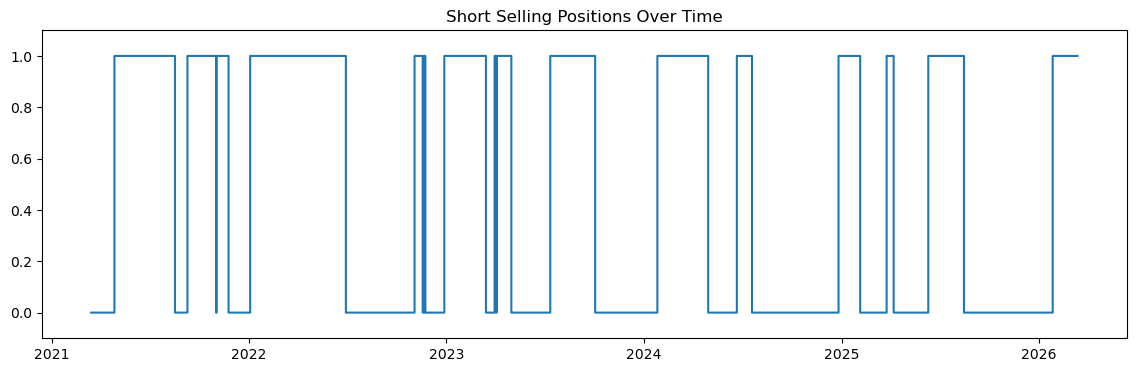

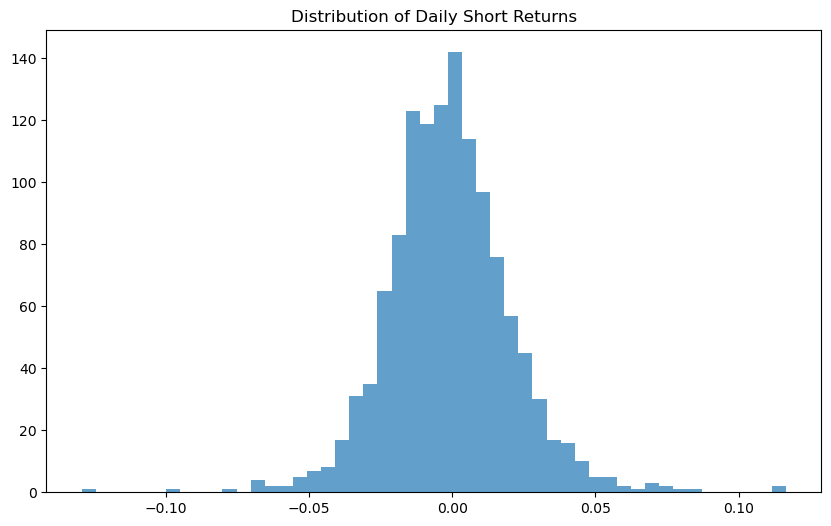

In [7]:
positions = [1 if r != 0 else 0 for r in strategy_returns]
plt.figure(figsize=(14,4))
plt.step(data.index, positions, label='Short Position (1=Short)')
plt.title('Short Selling Positions Over Time')
plt.ylim(-0.1, 1.1)
plt.show()

plt.figure(figsize=(10,6))
plt.hist(short_returns.dropna(), bins=50, alpha=0.7)
plt.title('Distribution of Daily Short Returns')
plt.show()

# Conclusion

Short selling USO can offer opportunities in declining oil markets but involves substantial risks including unlimited losses, margin calls, and additional costs from dividends and borrowing fees. Technical analysis and risk management are crucial. This notebook provides a concise analysis; real trading requires professional advice and current market conditions.

# Optimize RSI Conditions

To optimize the RSI entry and exit conditions for maximizing returns, we can perform a grid search over possible RSI thresholds. We'll test entry RSI levels from 60 to 80 and exit RSI levels from 20 to 40, in steps of 5, and calculate the total return for each combination.

Best Entry RSI: 80, Best Exit RSI: 25, Total Return: -0.3906


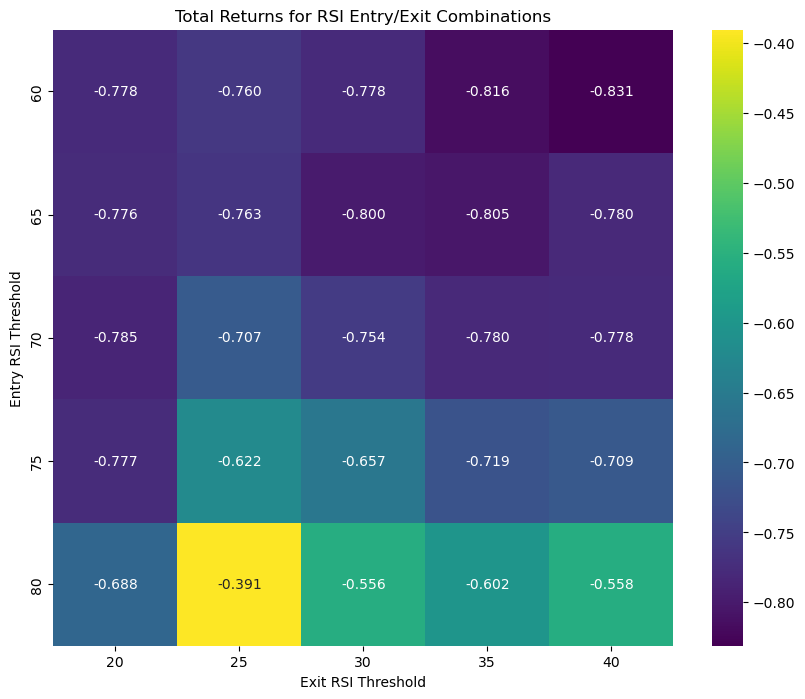

In [ ]:
entry_levels = list(range(60, 81, 5))
exit_levels = list(range(20, 41, 5))
returns_matrix = np.zeros((len(entry_levels), len(exit_levels)))

for i, entry in enumerate(entry_levels):
    for j, exit_rsi in enumerate(exit_levels):
        position = 0
        strat_ret = []
        for k in range(len(data)):
            if data['RSI'].iloc[k] > entry and position == 0:
                position = 1
            elif data['RSI'].iloc[k] < exit_rsi and position == 1:
                position = 0
            if position == 1:
                strat_ret.append(-data['Returns'].iloc[k])
            else:
                strat_ret.append(0)
        cum_ret = (1 + pd.Series(strat_ret)).cumprod().iloc[-1] - 1
        returns_matrix[i, j] = cum_ret

# Find best
max_idx = np.unravel_index(np.argmax(returns_matrix), returns_matrix.shape)
best_entry = entry_levels[max_idx[0]]
best_exit = exit_levels[max_idx[1]]
best_return = returns_matrix[max_idx]

print(f"Best Entry RSI: {best_entry}, Best Exit RSI: {best_exit}, Total Return: {best_return:.4f}")

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(returns_matrix, xticklabels=exit_levels, yticklabels=entry_levels, annot=True, fmt=".3f", cmap="viridis")
plt.title('Total Returns for RSI Entry/Exit Combinations')
plt.xlabel('Exit RSI Threshold')
plt.ylabel('Entry RSI Threshold')
plt.show()

# 3D Surface Plot for RSI only
X, Y = np.meshgrid(entry_levels, exit_levels)
fig3 = plt.figure(figsize=(12, 8))
ax3 = fig3.add_subplot(111, projection='3d')
surf3 = ax3.plot_surface(X, Y, returns_matrix.T, cmap='viridis', edgecolor='none')
ax3.set_xlabel('Entry RSI')
ax3.set_ylabel('Exit RSI')
ax3.set_zlabel('Total Return')
ax3.set_title('3D Surface: Returns for RSI Entry/Exit')
fig3.colorbar(surf3, shrink=0.5, aspect=5)
plt.show()

# Optimize with Distance to SMA 50

To further optimize, we can add a third parameter: the minimum distance (as a percentage) that the price must be above the 50-day SMA to enter a short position. This adds momentum confirmation. We'll optimize RSI entry, RSI exit, and distance threshold, then visualize the results in a 3D plot.

Best Entry RSI: 80, Best Exit RSI: 25, Best Distance: 0.09, Total Return: -0.3693


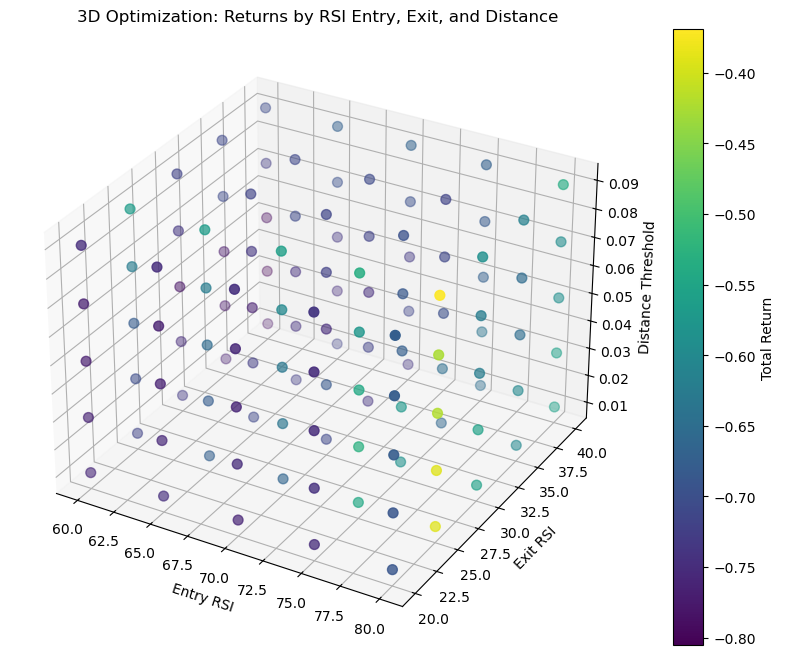

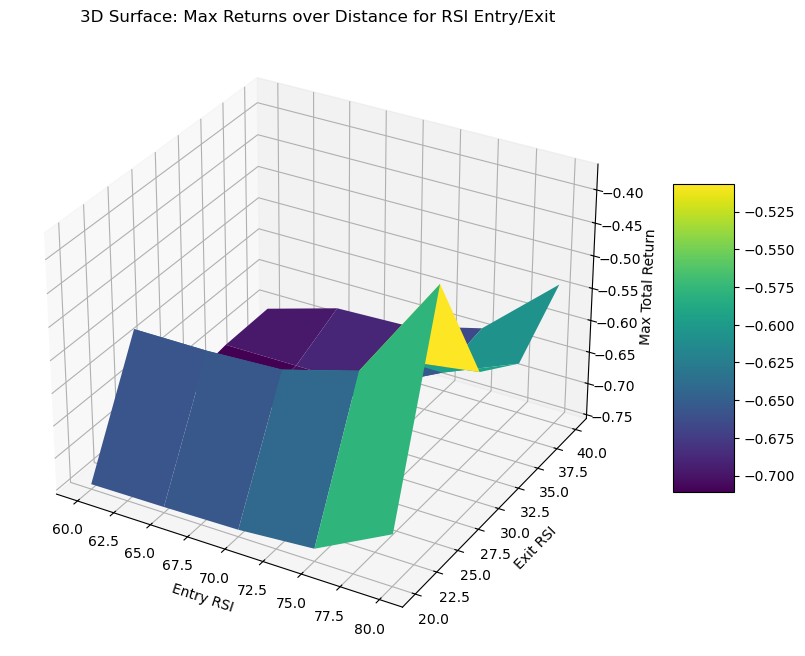

In [24]:
from mpl_toolkits.mplot3d import Axes3D

entry_rsi_levels = [60, 65, 70, 75, 80]
exit_rsi_levels = [20, 25, 30, 35, 40]
distance_levels = [0.01, 0.03, 0.05, 0.07, 0.09]

returns_3d = np.zeros((len(entry_rsi_levels), len(exit_rsi_levels), len(distance_levels)))

for i, entry_rsi in enumerate(entry_rsi_levels):
    for j, exit_rsi in enumerate(exit_rsi_levels):
        for k, dist in enumerate(distance_levels):
            position = 0
            strat_ret = []
            for m in range(len(data)):
                price_above_sma = (data['Close'].iloc[m] - data['SMA_50'].iloc[m]) / data['SMA_50'].iloc[m] > dist
                if data['RSI'].iloc[m] > entry_rsi and price_above_sma and position == 0:
                    position = 1
                elif data['RSI'].iloc[m] < exit_rsi and position == 1:
                    position = 0
                if position == 1:
                    strat_ret.append(-data['Returns'].iloc[m])
                else:
                    strat_ret.append(0)
            cum_ret = (1 + pd.Series(strat_ret)).cumprod().iloc[-1] - 1
            returns_3d[i, j, k] = cum_ret

# Find best
max_idx = np.unravel_index(np.argmax(returns_3d), returns_3d.shape)
best_entry_rsi = entry_rsi_levels[max_idx[0]]
best_exit_rsi = exit_rsi_levels[max_idx[1]]
best_dist = distance_levels[max_idx[2]]
best_return_3d = returns_3d[max_idx]

print(f"Best Entry RSI: {best_entry_rsi}, Best Exit RSI: {best_exit_rsi}, Best Distance: {best_dist}, Total Return: {best_return_3d:.4f}")

# 3D Plot: Scatter plot of all combinations
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Flatten for scatter
entry_flat = np.repeat(entry_rsi_levels, len(exit_rsi_levels) * len(distance_levels))
exit_flat = np.tile(np.repeat(exit_rsi_levels, len(distance_levels)), len(entry_rsi_levels))
dist_flat = np.tile(distance_levels, len(entry_rsi_levels) * len(exit_rsi_levels))
returns_flat = returns_3d.flatten()

sc = ax.scatter(entry_flat, exit_flat, dist_flat, c=returns_flat, cmap='viridis', s=50)
ax.set_xlabel('Entry RSI')
ax.set_ylabel('Exit RSI')
ax.set_zlabel('Distance Threshold')
ax.set_title('3D Optimization: Returns by RSI Entry, Exit, and Distance')
plt.colorbar(sc, label='Total Return')
plt.show()

# 3D Surface Plot: Max return over distances for each RSI pair
max_returns_2d = np.max(returns_3d, axis=2)  # max over distance dimension
X, Y = np.meshgrid(entry_rsi_levels, exit_rsi_levels)

fig2 = plt.figure(figsize=(12, 8))
ax2 = fig2.add_subplot(111, projection='3d')
surf = ax2.plot_surface(X, Y, max_returns_2d.T, cmap='viridis', edgecolor='none')
ax2.set_xlabel('Entry RSI')
ax2.set_ylabel('Exit RSI')
ax2.set_zlabel('Max Total Return')
ax2.set_title('3D Surface: Max Returns over Distance for RSI Entry/Exit')
fig2.colorbar(surf, shrink=0.5, aspect=5)
plt.show()